In [1]:
print("Project 4: Outfit Recommender V2")

Project 4: Outfit Recommender V2


In [11]:
import os
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity

In [12]:
IMAGE_FOLDER = "../images"

files = os.listdir(IMAGE_FOLDER)

print("Number of images:", len(files))
print(files[:5])

Number of images: 26
['#outfits #fashion #summer #summerstyle.jpg', '30 Effortlessly Chic Outfits to Copy for Summer.jpg', '5 Summer Outfits To Wear In The Hamptons - The Girl from Panama.jpg', 'Another Day in Denim.jpg', 'download (1).jpg']


In [13]:
def get_features(image_path, n_colors=3):
    img = Image.open(image_path).convert("RGB")
    img = img.resize((100, 100))  # speed + consistency

    img_array = np.array(img).reshape(-1, 3)

    # --- Dominant colors (same as V1) ---
    kmeans = KMeans(n_clusters=n_colors, random_state=42)
    kmeans.fit(img_array)
    colors = kmeans.cluster_centers_

    # --- NEW: Brightness ---
    brightness = np.mean(img_array)

    # --- NEW: Contrast ---
    contrast = np.std(img_array)

    # --- Combine everything ---
    feature_vector = np.concatenate([colors.flatten(), [brightness, contrast]])

    return feature_vector

In [14]:
all_features = []

for file in files:
    path = os.path.join(IMAGE_FOLDER, file)
    features = get_features(path)
    all_features.append(features)

all_features = np.array(all_features)

print("Feature shape:", all_features.shape)

Feature shape: (26, 11)


In [15]:
style_model = KMeans(n_clusters=3, random_state=42)
style_labels = style_model.fit_predict(all_features)

style_names = {
    0: "Neutral / Minimal",
    1: "Dark / Streetwear",
    2: "Light / Casual"
}

C:\Users\ousama\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [16]:
def recommend_similar_outfits(image_path, top_n=3):
    new_feature = get_features(image_path)

    similarities = cosine_similarity([new_feature], all_features)[0]

    input_filename = os.path.basename(image_path)
    input_index = files.index(input_filename)
    input_style = style_labels[input_index]

    print("Input style:", style_names[input_style])

    sorted_indexes = similarities.argsort()[::-1]

    shown = 0

    for index in sorted_indexes:
        file = files[index]

        if file == input_filename:
            continue

        if style_labels[index] != input_style:
            continue

        score = similarities[index]

        img_path = os.path.join(IMAGE_FOLDER, file)
        img = Image.open(img_path).convert("RGB")

        print(f"{file} → similarity: {score:.3f}")

        plt.imshow(img)
        plt.title(f"{style_names[input_style]}\n{file}\nSimilarity: {score:.3f}")
        plt.axis("off")
        plt.show()

        shown += 1

        if shown >= top_n:
            break

Input style: Light / Casual
LAURA JADE NUDE HIGH WAISTED MIDI SKIRT WITH BUTTON SIDE SPLIT.jpg → similarity: 0.995


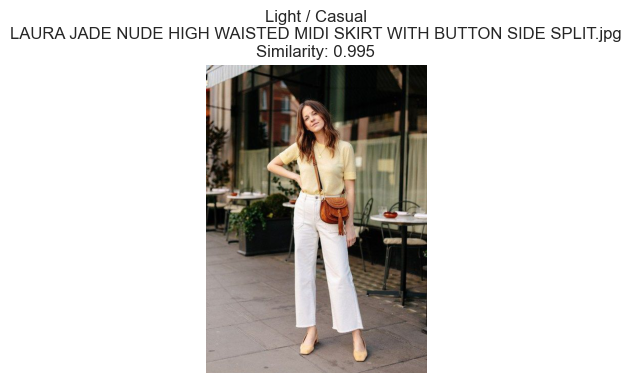

Rose.jpg → similarity: 0.991


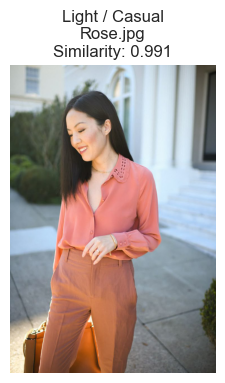

download (5).jpg → similarity: 0.988


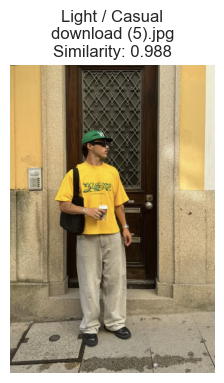

In [17]:
test_image = os.path.join(IMAGE_FOLDER, files[0])
recommend_similar_outfits(test_image, top_n=3)